<h4>The 1st component model - Technical Analysis Model</h4>

In [158]:
# !pip install scikeras
# !pip install backtrader

In [159]:
# Libraries for machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

# Libraries for Deep Learning Models
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import LSTM
from scikeras.wrappers import KerasRegressor

# Libraries for Statistical Models
import statsmodels.api as sm

# Libraries for Saving the Model
from pickle import dump
from pickle import load

# Libraries for Time series Models
from statsmodels.tsa.arima.model import ARIMA

# Libraries for Error Metrics
from sklearn.metrics import mean_squared_error

# Libraries for Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_regression

# Libraries for Plotting
from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf

# Import for trade simulation
import backtrader as bt
import backtrader.indicators as btind
import backtrader.analyzers as btanalyzers

# Import other general use libraries
import numpy as np
import pandas as pd
import yfinance as yf
from matplotlib import pyplot
from pandas.plotting import scatter_matrix
from datetime import date, datetime, timedelta
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib

In [160]:
# The data period used to train and test the component models is 2025/1/1 to 2025/12/31.
# The data period used to train and test the combined model is 2023/12/1 to 2024/11/30.
# However, as the technical analysis needs more data to calculate the financial indicator, below extract data from 2022/1/1 to 2025/12/31.
# On the other hand, below also include the data period for the training and testing of the combined model.
endDate = date(2025, 12, 31)
startDate = date(2022, 1, 1) # as more data is need to calculate financial indicator

# For technical analysis, as it can be stock/index specific while the training time is not long.
# The training of model can be perform with each user input of ticker.
# Below is just using S&P500 to settle the method and demonstrate the process.
target_tickers = ['^GSPC']
target_data = yf.download(target_tickers, start = startDate, end = endDate, interval = '1d')

# other general index/asset commonly related to the price of stock/index.
reference_tickers = ['^GSPC', '^IXIC', '^DJI', '^VIX', 'DX-Y.NYB', 'BTC-USD']
reference_data = yf.download(reference_tickers, start = startDate, end = endDate, interval = '1d')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  6 of 6 completed


In [161]:
# building own indicators - group 1
df = target_data
df = df.dropna()
df = df.sort_values(by = 'Date', ascending = True)
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
df['prevReturn_1Ddelay'] = df['Open'].pct_change()
df['curReturn'] = df['prevReturn_1Ddelay'].shift(-1)
df['prevReturn_2Ddelay'] = df['curReturn'].shift(2)
df['prevReturn_3Ddelay'] = df['curReturn'].shift(3)
df['prevReturn_4Ddelay'] = df['curReturn'].shift(4)
df['prevReturn_5Ddelay'] = df['curReturn'].shift(5)

In [162]:
# building own indicators - group 2

# rate of change
def ROC(df, n):
  M = df.diff(n - 1)
  N = df.shift(n - 1)
  ROC = pd.Series(((M / N) * 100), name = 'ROC_' + str(n))
  return ROC
df['ROC_10'] = ROC(df['Open'], 10)
df['ROC_20'] = ROC(df['Open'], 20)
df['ROC_30'] = ROC(df['Open'], 30)

# price momentum
def MOM(df, n):
  MOM = pd.Series(df.diff(n), name = 'Momentum_' + str(n))
  return MOM
df['MOM_10'] = MOM(df['Open'], 10)
df['MOM_20'] = MOM(df['Open'], 20)
df['MOM_30'] = MOM(df['Open'], 30)

# relative strength index
def RSI(series, period):
  delta = series.diff().dropna()
  u = delta * 0
  d = u.copy()
  u[delta > 0] = delta[delta > 0]
  d[delta < 0] = -delta[delta < 0]
  u[u.index[period-1]] = np.mean( u[:period] )
  u = u.drop(u.index[:(period - 1)])
  d[d.index[period - 1]] = np.mean( d[:period] )
  d = d.drop(d.index[:(period - 1)])
  rs = u.ewm(com = period - 1, adjust = False).mean() / d.ewm(com = period - 1, adjust = False).mean()
  return 100 - 100 / (1 + rs)
df['RSI_15'] = RSI(df['Open'], 15)
df['RSI_30'] = RSI(df['Open'], 30)
df['RSI_60'] = RSI(df['Open'], 60)

# stochastic oscillator
def STOK(close, low, high, n):
  STOK = ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100
  return STOK
def STOD(close, low, high, n):
  STOK = ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100
  STOD = STOK.rolling(3).mean()
  return STOD
df['STOD_%K_15'] = STOK(df['Close'], df['Low'], df['High'], 15)
df['STOD_%K_30'] = STOK(df['Close'], df['Low'], df['High'], 30)
df['STOD_%K_60'] = STOK(df['Close'], df['Low'], df['High'], 60)
df['STOD_%D_15'] = STOD(df['Close'], df['Low'], df['High'], 15)
df['STOD_%D_30'] = STOD(df['Close'], df['Low'], df['High'], 30)
df['STOD_%D_60'] = STOD(df['Close'], df['Low'], df['High'], 60)

df = df[['curReturn', 'prevReturn_1Ddelay', 'prevReturn_2Ddelay', 'prevReturn_3Ddelay', 'prevReturn_4Ddelay', 'prevReturn_5Ddelay', 'ROC_10', 'ROC_20', 'ROC_30', 'MOM_10', 'MOM_20', 'MOM_30', 'RSI_15', 'RSI_30', 'RSI_60', 'STOD_%K_15', 'STOD_%K_30', 'STOD_%K_60', 'STOD_%D_15', 'STOD_%D_30', 'STOD_%D_60']]
# df

In [163]:
# other financial index/asset for reference - previous day return only
df_other = reference_data['Open']
df_other = df_other.dropna()
df_other = df_other.sort_values(by = 'Date', ascending = True)
df_other = df_other.pct_change()
df = pd.merge(df, df_other, how = 'left', left_on = ['Date'], right_on = ['Date'])
df = df.dropna()
df = df.sort_values(by = 'Date', ascending = True)
df = df.loc[:, df.columns != target_tickers[0]]
# df

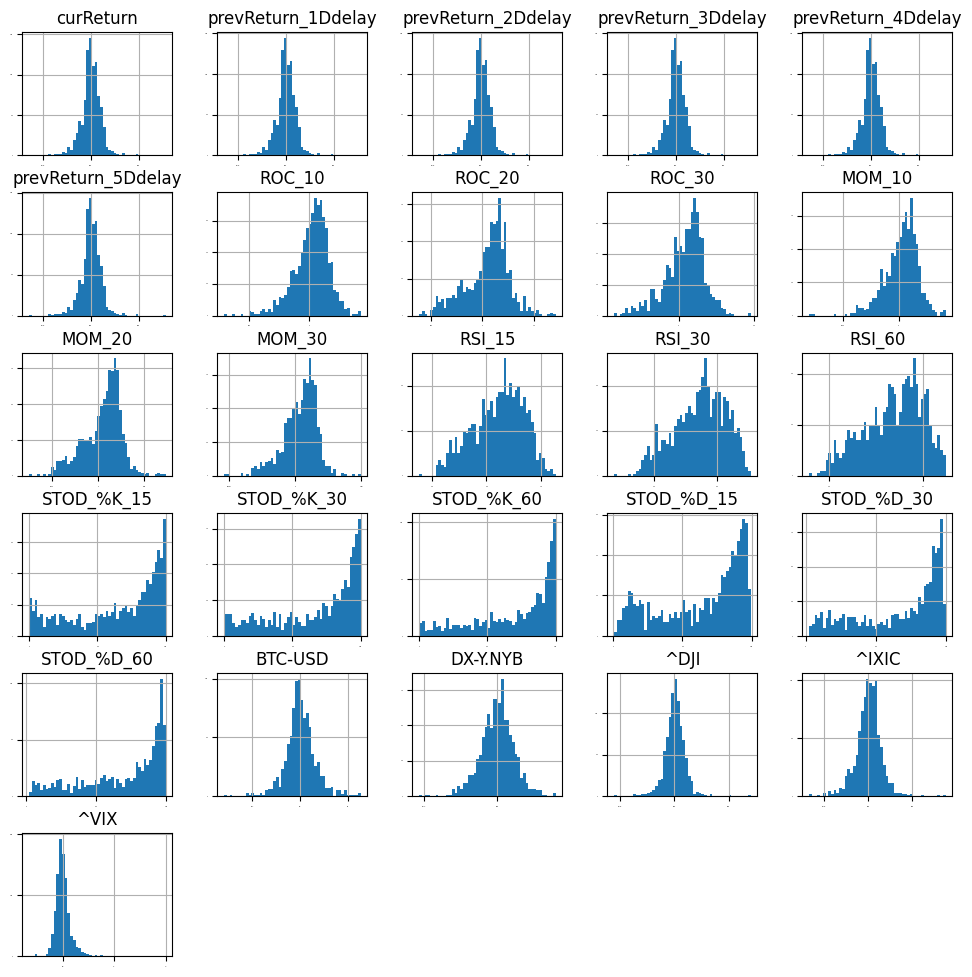

<Axes: title={'center': 'Correlation Matrix'}>

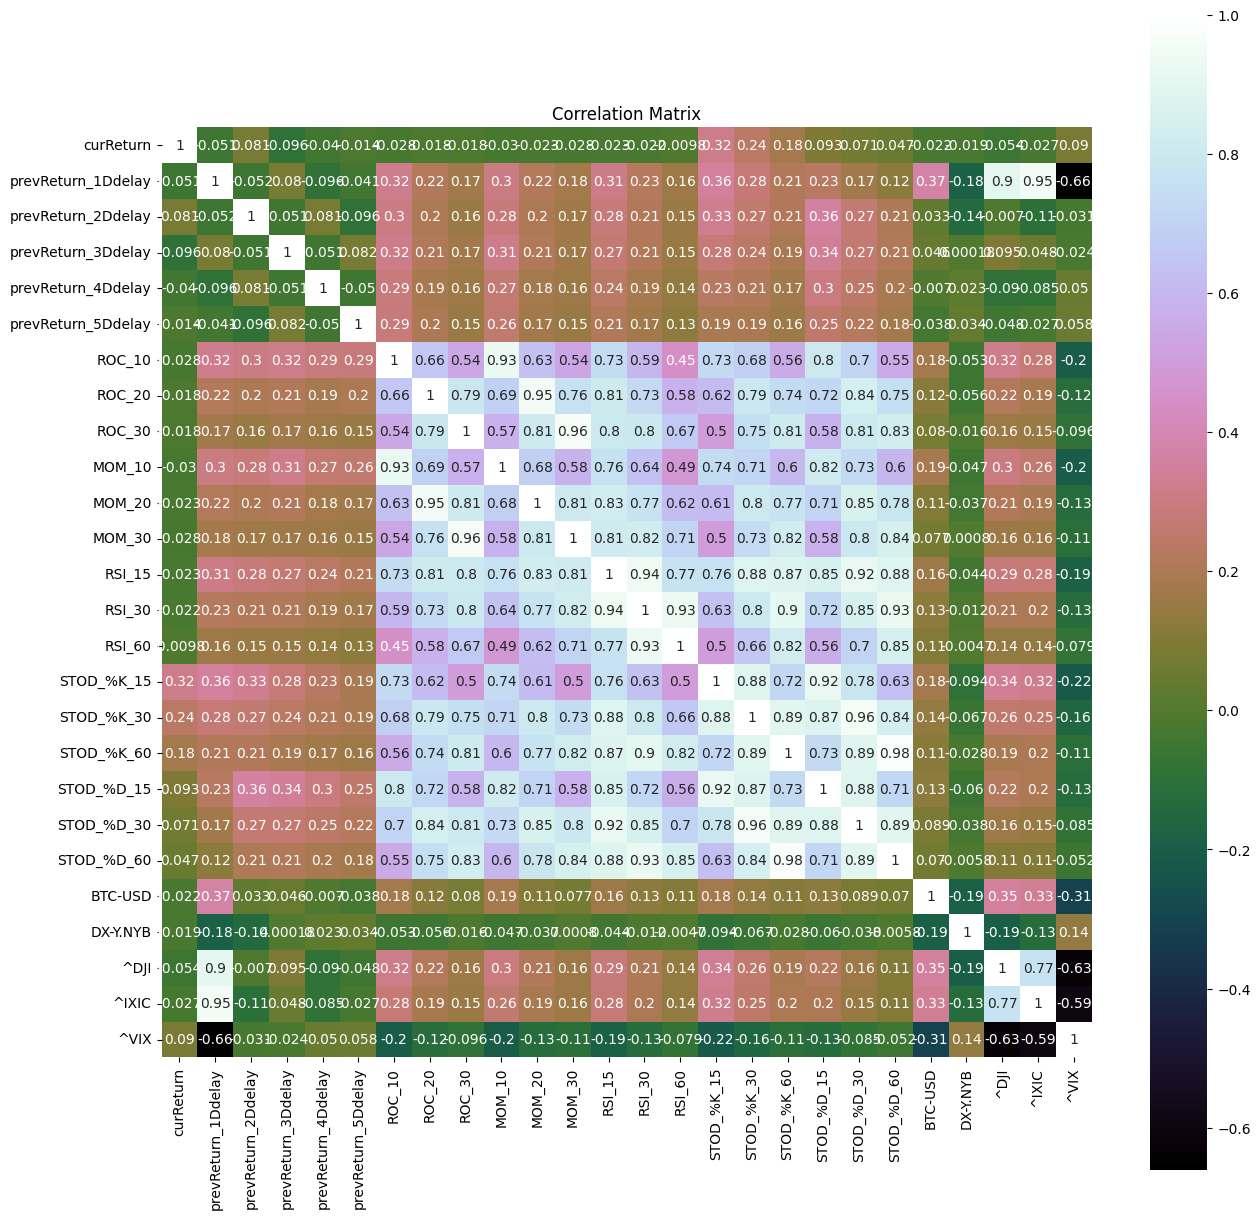

In [164]:
# Descriptive Statistics
df.describe()
# Data Visualization - histogram
df.hist(bins = 50, sharex = False, sharey = False, xlabelsize = 1, ylabelsize = 1, figsize = (12, 12))
pyplot.show()
# Data Visualization - Correlation Matrix
correlation = df.corr()
pyplot.figure(figsize = (15, 15))
pyplot.title('Correlation Matrix')
sns.heatmap(correlation, vmax = 1, square = True, annot = True, cmap = 'cubehelix')

In [165]:
# Ready Data for training and testing
Y = df.loc[:, 'curReturn']
Y = Y[Y.index >= '2025-01-01']
X = df.loc[:, df.columns != 'curReturn']
X = X[X.index >= '2025-01-01']

# Use sklearn's SelectKBest function to get features' importance
bestfeatures = SelectKBest(k = 5, score_func = f_regression)
fit = bestfeatures.fit(X, Y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns, dfscores], axis = 1)
featureScores.columns = ['Specs', 'Score']
featureScores.nlargest(25, 'Score').set_index('Specs')

,Score
Specs,
STOD_%K_15,21.778854
^VIX,21.723517
prevReturn_2Ddelay,19.719627
prevReturn_1Ddelay,19.529984
^IXIC,16.433260
^DJI,15.433848
STOD_%K_30,14.544052
prevReturn_3Ddelay,9.686928
STOD_%K_60,9.194309


In [166]:
# Train Test Split. Since this is time series, just split without shuffle.
validation_size = 0.3
train_size = int(len(X) * (1 - validation_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(X)]

In [167]:
# Basics model settings
num_folds = 10
seed = 7
scoring = 'neg_mean_squared_error'

# Compare Models - Regression and Tree Regression algorithms
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))

# Compare Models - Ensemble Models
# Boosting methods
models.append(('ABR', AdaBoostRegressor()))
models.append(('GBR', GradientBoostingRegressor()))
# Bagging methods
models.append(('RFR', RandomForestRegressor()))
models.append(('ETR', ExtraTreesRegressor()))

In [168]:
# loop throught models
names = []
kfold_results = []
test_results = []
train_results = []
for name, model in models:
    names.append(name)

    # K Fold analysis
    kfold = KFold(n_splits = num_folds, random_state = seed, shuffle = True)
    cv_results = -1 * cross_val_score(model, X_train, Y_train, cv = kfold, scoring = scoring)
    kfold_results.append(cv_results)

    # Training
    res = model.fit(X_train, Y_train)
    train_result = mean_squared_error(res.predict(X_train), Y_train)
    train_results.append(train_result)

    # Test
    test_result = mean_squared_error(res.predict(X_test), Y_test)
    test_results.append(test_result)

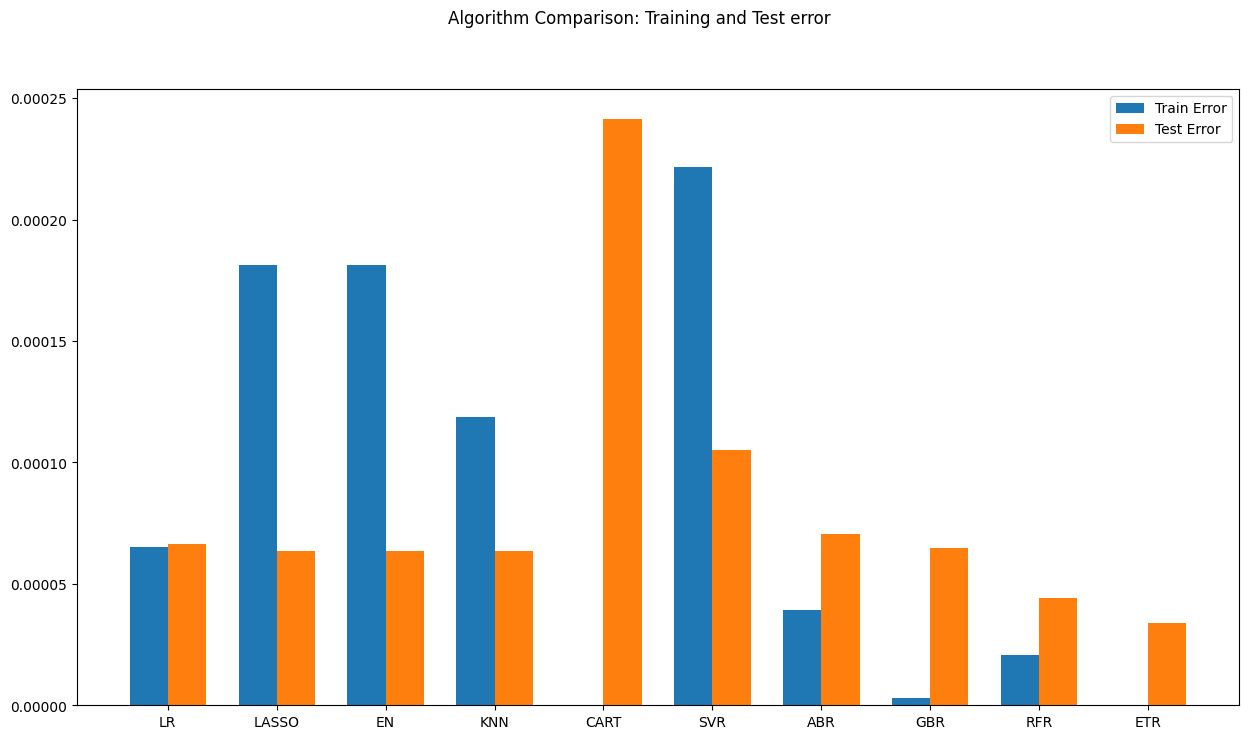

In [169]:
# Compare Training and Test error
fig = pyplot.figure()
ind = np.arange(len(names))
width = 0.35

fig.suptitle('Algorithm Comparison: Training and Test error')
ax = fig.add_subplot(111)
pyplot.bar(ind - width / 2, train_results,  width = width, label = 'Train Error')
pyplot.bar(ind + width / 2, test_results, width = width, label = 'Test Error')
fig.set_size_inches(15, 8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

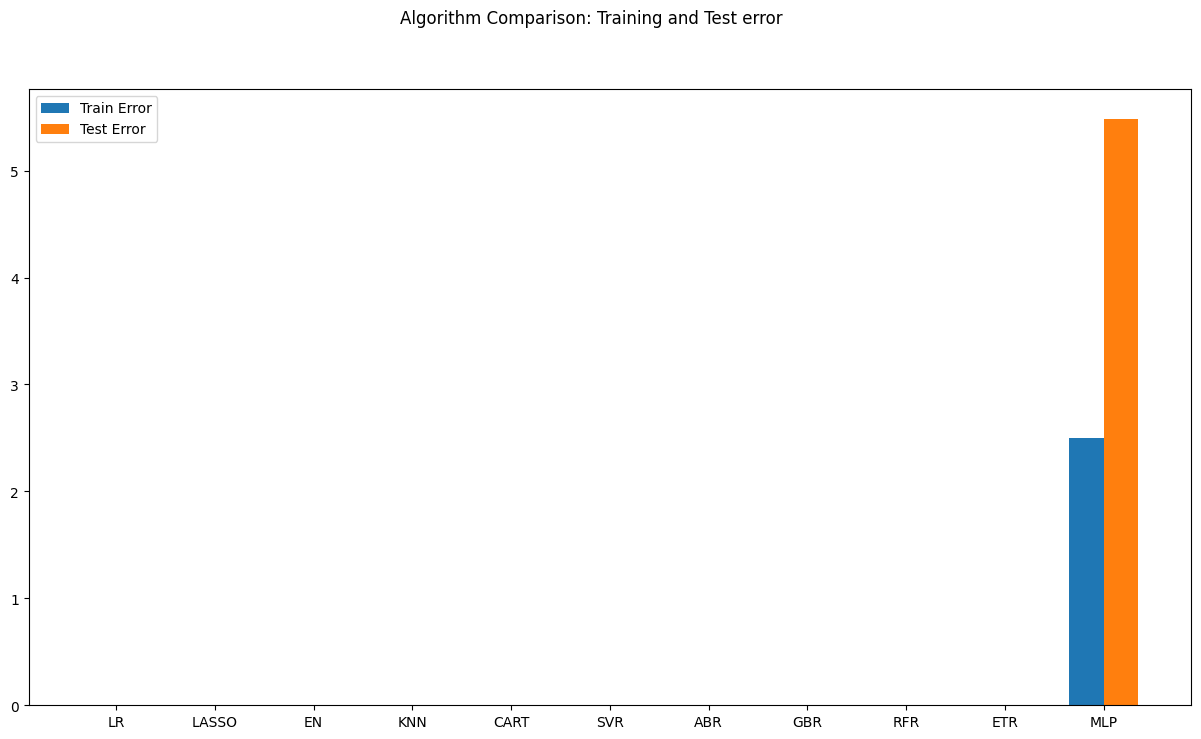

In [170]:
# Compare Models - Neural Network algorithms
models.append(('MLP', MLPRegressor()))
name = models[-1][0]
model = models[-1][1]

names.append(name)

# K Fold analysis
kfold = KFold(n_splits = num_folds, random_state = seed, shuffle = True)
cv_results = -1 * cross_val_score(model, X_train, Y_train, cv = kfold, scoring = scoring)
kfold_results.append(cv_results)

# Training
res = model.fit(X_train, Y_train)
train_result = mean_squared_error(res.predict(X_train), Y_train)
train_results.append(train_result)

# Test
test_result = mean_squared_error(res.predict(X_test), Y_test)
test_results.append(test_result)

# Compare Training and Test error
fig = pyplot.figure()
ind = np.arange(len(names))
width = 0.35

fig.suptitle('Algorithm Comparison: Training and Test error')
ax = fig.add_subplot(111)
pyplot.bar(ind - width / 2, train_results,  width = width, label = 'Train Error')
pyplot.bar(ind + width / 2, test_results, width = width, label = 'Test Error')
fig.set_size_inches(15, 8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

In [171]:
# the result of MLP is so bad that need to take out from comparison
names.pop()
kfold_results.pop()
test_results.pop()
train_results.pop()
pass

In [172]:
# Compare Models - ARIMA
modelARIMA = ARIMA(endog = Y_train, exog = X_train, order=[1, 1, 1])
model_fit = modelARIMA.fit()

error_Training_ARIMA = mean_squared_error(Y_train, model_fit.fittedvalues)
predicted = model_fit.predict(start = len(X_train) - 1 ,end = len (X) - 1, exog = X_test)[1:]
error_Test_ARIMA = mean_squared_error(Y_test, predicted)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


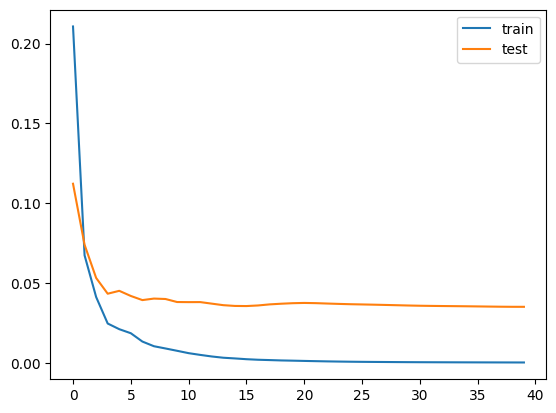

In [173]:
# Compare Models - LSTM
seq_len = 2
Y_train_LSTM, Y_test_LSTM = np.array(Y_train)[seq_len - 1:], np.array(Y_test)
X_train_LSTM = np.zeros((X_train.shape[0] + 1 - seq_len, seq_len, X_train.shape[1]))
X_test_LSTM = np.zeros((X_test.shape[0], seq_len, X.shape[1]))
for i in range(seq_len):
    X_train_LSTM[:, i, :] = np.array(X_train)[i:X_train.shape[0] + i + 1 - seq_len, :]
    X_test_LSTM[:, i, :] = np.array(X)[X_train.shape[0] + i - 1:X.shape[0] + i + 1 - seq_len, :]

# LSTM Network
def create_LSTMmodel(neurons = 12, learn_rate = 0.01, momentum = 0):
    # create model
    model = Sequential()
    model.add(LSTM(100, input_shape=(X_train_LSTM.shape[1], X_train_LSTM.shape[2])))
    model.add(Dense(1))
    optimizer = SGD(learning_rate = learn_rate, momentum = momentum)
    model.compile(loss = 'mse', optimizer = 'adam')
    return model
LSTMModel = create_LSTMmodel(12, learn_rate = 0.001, momentum = 0.001)
LSTMModel_fit = LSTMModel.fit(X_train_LSTM, Y_train_LSTM, validation_data = (X_test_LSTM, Y_test_LSTM), epochs = 40, batch_size = 72, verbose = 0, shuffle = False)

error_Training_LSTM = mean_squared_error(Y_train_LSTM, LSTMModel.predict(X_train_LSTM))
predicted = LSTMModel.predict(X_test_LSTM)
error_Test_LSTM = mean_squared_error(Y_test, predicted)

# Visual plot to check if the error is reducing
pyplot.plot(LSTMModel_fit.history['loss'], label='train')
pyplot.plot(LSTMModel_fit.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

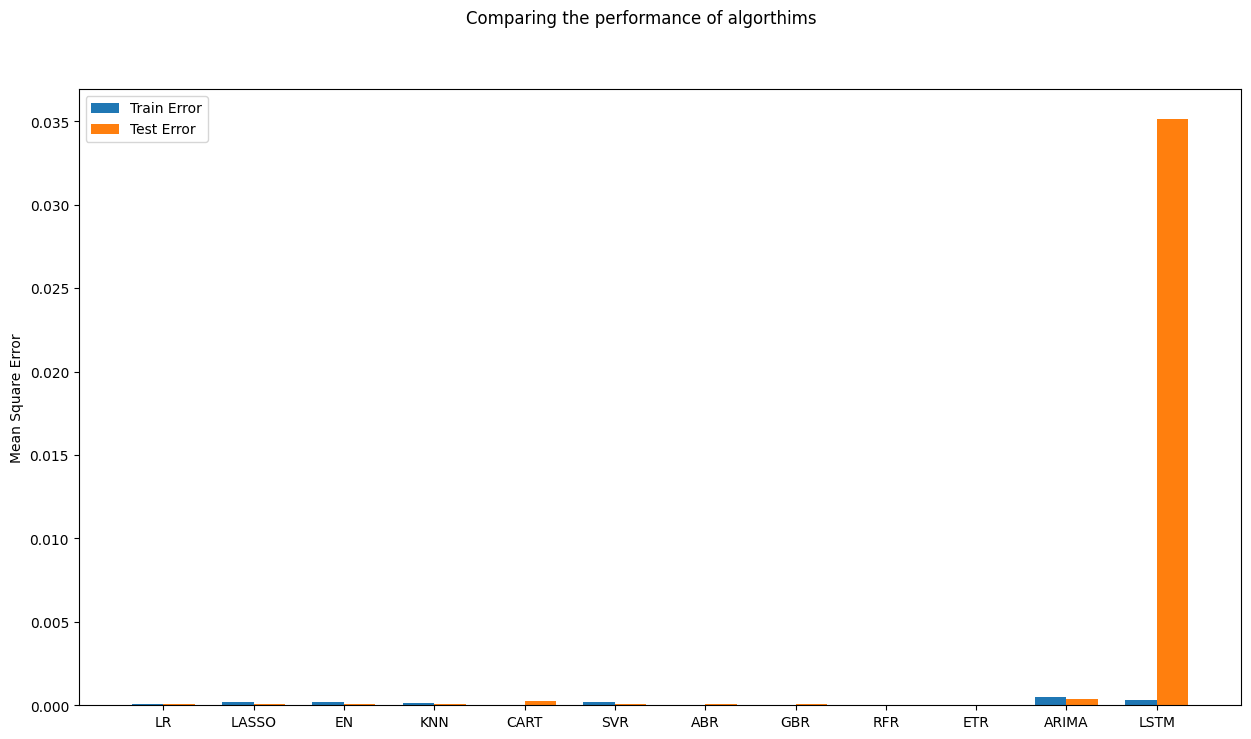

In [174]:
# Append the models to previous results for comparison
test_results.append(error_Test_ARIMA)
test_results.append(error_Test_LSTM)
train_results.append(error_Training_ARIMA)
train_results.append(error_Training_LSTM)
names.append("ARIMA")
names.append("LSTM")

# Compare Training and Test error for all algorithms
fig = pyplot.figure()
ind = np.arange(len(names))
width = 0.35

fig.suptitle('Comparing the performance of algorthims')
ax = fig.add_subplot(111)
pyplot.bar(ind - width / 2, train_results,  width = width, label = 'Train Error')
pyplot.bar(ind + width / 2, test_results, width = width, label = 'Test Error')
fig.set_size_inches(15, 8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.ylabel('Mean Square Error')
pyplot.show()

In [175]:
# after trying above method, decide to use Linear Regression model as it is doing well compare to other machine learning models while remaining simple and commonly used in finance
model_LR = models[0][1]

# apply the model on data range that used to train and test the combined model
df_sim = df[df.index <= '2024-11-30']
df_sim = df_sim[df_sim.index >= '2023-12-1']
Y_sim = df_sim.loc[:, 'curReturn']
X_sim = df_sim.loc[:, df_sim.columns != 'curReturn']

In [176]:
# after choosing LR is the method to use, use backtrader package to simulate the trading process

# setting up the backtrader simulation
class Indicate(bt.Indicator):
  lines = ('indicate',)
  plotinfo = dict(plotymargin = 0.5, plothlines = [0], plotyticks = [1.0, 0, -1.0])

  def next(self):
    self.indicate = 0.0
    self.date = self.data.datetime
    date = bt.num2date(self.date[0]).date()
    if date in date_indicate:
      self.indicate = date_indicate[date]
    self.lines.indicate[0] = self.indicate


class IndicateStrategy(bt.Strategy):
  params = (('period', 15), ('printlog', True),)

  def log(self, txt, dt=None, doprint=False):
    if self.params.printlog or doprint:
      dt = dt or self.datas[0].datetime.date(0)
      if showTradingDetails:
        print('%s, %s' % (dt.isoformat(), txt))

  def __init__(self):
    self.dataclose = self.datas[0].close
    self.order = None
    self.buyprice = None
    self.buycomm = None
    self.date = self.data.datetime
    self.indicate = None
    Indicate(self.data)
    self.plotinfo.plot = False

  def notify_order(self, order):
    if order.status in [order.Submitted, order.Accepted]:
      return
    if order.status in [order.Completed]:
      if order.isbuy(): # Buy
        if showTradingDetails:
          self.log('Buy @ %.2f' % (order.executed.price))
        self.buyprice = order.executed.price
        self.buycomm = order.executed.comm
      else:  # Sell
        if showTradingDetails:
          self.log('Sell @ %.2f' % (order.executed.price))
      self.bar_executed = len(self)
    elif order.status in [order.Canceled, order.Margin, order.Rejected]:
      if showTradingDetails:
        self.log('Order Canceled/Margin/Rejected')
    self.order = None

  def notify_trade(self, trade):
    if not trade.isclosed:
      return
    if showTradingDetails:
      self.log('^ Profit %.2f' % (trade.pnl))

  # Strategy
  def next(self):
    date = bt.num2date(self.date[0]).date()
    if date in date_indicate:
      self.indicate = date_indicate[date]
    # Check if any pending order
    if self.order:
      return
    # Check if Buy already
    if not self.position: # not in buy position
      if self.indicate >= buyTrigger:
        self.order = self.buy()
    elif self.position: # in buy position
      if self.indicate < buyTrigger:
        self.order = self.sell()

def run_strategy(ticker, start, end):
  ticker = yf.Ticker(ticker)
  df_ticker = ticker.history(start = start, end = end)
  cerebro = bt.Cerebro(cheat_on_open=True) # buy at open
  cerebro.addstrategy(IndicateStrategy)
  data = bt.feeds.PandasData(dataname = df_ticker)
  cerebro.adddata(data)
  startMoney = 100
  cerebro.broker.setcash(startMoney)
  cerebro.addsizer(bt.sizers.PercentSizer, percents = 98)
  if showTradingDetails:
    print('Starting Value: ' + str(startMoney))
  cerebro.run()
  endMoney = cerebro.broker.getvalue()
  if showTradingDetails:
    print('Ending Portfolio Value: %.2f\nProfit: %.2f\n' % (endMoney, (endMoney - startMoney)))
  return (endMoney - startMoney)

In [177]:
# get the indicator and other data ready for simulation
Y_sim = Y_sim.reset_index()
Y_est = model_LR.predict(X_sim)
Y_est = pd.DataFrame(Y_est, columns = ['TA_estReturn'])
temp_df = pd.merge(Y_sim, Y_est, left_index = True, right_index = True, how = 'inner')

date_indicate = temp_df[['Date','TA_estReturn']]
date_indicate['Date'] = pd.to_datetime(date_indicate['Date']).dt.date
date_indicate = date_indicate.sort_values(by = 'Date', ascending = True)
date_indicate = date_indicate.set_index('Date')['TA_estReturn']
date_indicate = date_indicate.to_dict()

In [178]:
# in the simulation, if the indicator is higher/lower than some trigger value, perform buy/sell
# below check which trigger value to use, by trying out differnet n-th percentile
bestSettings = [0, 0] # profit, buyTrigger
showTradingDetails = False
for i in range(1, 100):
  buyTrigger = np.percentile(Y_est['TA_estReturn'], i)
  profit = run_strategy(target_tickers[0], start = Y_sim['Date'].min(), end = Y_sim['Date'].max())
  if profit > bestSettings[0]:
    bestSettings = [profit, buyTrigger]

# run the sumulation with the best trigger values found
showTradingDetails = True
buyTrigger = bestSettings[1]
profit = run_strategy(target_tickers[0], start = Y_sim['Date'].min(), end = Y_sim['Date'].max())

Starting Value: 100
2023-12-04, Buy @ 4564.37
2024-04-18, Sell @ 5031.52
2024-04-18, ^ Profit 9.96
2024-04-19, Buy @ 5005.44
2024-08-02, Sell @ 5376.63
2024-08-02, ^ Profit 7.98
2024-08-05, Buy @ 5151.14
2024-11-01, Sell @ 5723.22
2024-11-01, ^ Profit 12.37
2024-11-04, Buy @ 5725.15
Ending Portfolio Value: 136.41
Profit: 36.41



In [179]:
# After showing the model is valid, we can save the model.
# However, as the model is ticker specific while the training time is not long, the final product shoud train the model with the same method instantly.
joblib.dump(model_LR, 'TA_model.sav')

# save the returns estimated for the training and testing of the combined model
estReturn = temp_df[['Date','TA_estReturn']]
estReturn.to_csv('TA_Data.csv')

In [180]:
# below shows how to perform technical analysis on latest financial data
# ticker input
target_tickers = ['^GSPC']
reference_tickers = ['^GSPC', '^IXIC', '^DJI', '^VIX', 'DX-Y.NYB', 'BTC-USD']

# get all the features needed for training the model and estimating the return
endDate = date.today()
startDate = endDate - timedelta(days = 365)
target_data = yf.download(target_tickers, start = startDate, end = endDate, interval = '1d')
reference_data = yf.download(reference_tickers, start = startDate, end = endDate, interval = '1d')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  6 of 6 completed


In [181]:
# building own indicators - group 1
df = target_data
df = df.dropna()
df = df.sort_values(by = 'Date', ascending = True)
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
df['prevReturn_1Ddelay'] = df['Open'].pct_change()
df['curReturn'] = df['prevReturn_1Ddelay'].shift(-1)
df['prevReturn_2Ddelay'] = df['curReturn'].shift(2)
df['prevReturn_3Ddelay'] = df['curReturn'].shift(3)
df['prevReturn_4Ddelay'] = df['curReturn'].shift(4)
df['prevReturn_5Ddelay'] = df['curReturn'].shift(5)

In [182]:
# building own indicators - group 2

# rate of change
def ROC(df, n):
  M = df.diff(n - 1)
  N = df.shift(n - 1)
  ROC = pd.Series(((M / N) * 100), name = 'ROC_' + str(n))
  return ROC
df['ROC_10'] = ROC(df['Open'], 10)
df['ROC_20'] = ROC(df['Open'], 20)
df['ROC_30'] = ROC(df['Open'], 30)

# price momentum
def MOM(df, n):
  MOM = pd.Series(df.diff(n), name = 'Momentum_' + str(n))
  return MOM
df['MOM_10'] = MOM(df['Open'], 10)
df['MOM_20'] = MOM(df['Open'], 20)
df['MOM_30'] = MOM(df['Open'], 30)

# relative strength index
def RSI(series, period):
  delta = series.diff().dropna()
  u = delta * 0
  d = u.copy()
  u[delta > 0] = delta[delta > 0]
  d[delta < 0] = -delta[delta < 0]
  u[u.index[period-1]] = np.mean( u[:period] )
  u = u.drop(u.index[:(period - 1)])
  d[d.index[period - 1]] = np.mean( d[:period] )
  d = d.drop(d.index[:(period - 1)])
  rs = u.ewm(com = period - 1, adjust = False).mean() / d.ewm(com = period - 1, adjust = False).mean()
  return 100 - 100 / (1 + rs)
df['RSI_15'] = RSI(df['Open'], 15)
df['RSI_30'] = RSI(df['Open'], 30)
df['RSI_60'] = RSI(df['Open'], 60)

# stochastic oscillator
def STOK(close, low, high, n):
  STOK = ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100
  return STOK
def STOD(close, low, high, n):
  STOK = ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100
  STOD = STOK.rolling(3).mean()
  return STOD
df['STOD_%K_15'] = STOK(df['Close'], df['Low'], df['High'], 15)
df['STOD_%K_30'] = STOK(df['Close'], df['Low'], df['High'], 30)
df['STOD_%K_60'] = STOK(df['Close'], df['Low'], df['High'], 60)
df['STOD_%D_15'] = STOD(df['Close'], df['Low'], df['High'], 15)
df['STOD_%D_30'] = STOD(df['Close'], df['Low'], df['High'], 30)
df['STOD_%D_60'] = STOD(df['Close'], df['Low'], df['High'], 60)

df = df[['curReturn', 'prevReturn_1Ddelay', 'prevReturn_2Ddelay', 'prevReturn_3Ddelay', 'prevReturn_4Ddelay', 'prevReturn_5Ddelay', 'ROC_10', 'ROC_20', 'ROC_30', 'MOM_10', 'MOM_20', 'MOM_30', 'RSI_15', 'RSI_30', 'RSI_60', 'STOD_%K_15', 'STOD_%K_30', 'STOD_%K_60', 'STOD_%D_15', 'STOD_%D_30', 'STOD_%D_60']]
# df

In [183]:
# other financial asset for reference - previous day return only
df_other = reference_data['Open']
df_other = df_other.dropna()
df_other = df_other.sort_values(by = 'Date', ascending = True)
df_other = df_other.pct_change()
df = pd.merge(df, df_other, how = 'left', left_on = ['Date'], right_on = ['Date'])
df = df.dropna()
df = df.sort_values(by = 'Date', ascending = True)
df = df.loc[:, df.columns != target_tickers[0]]

In [184]:
# Ready Data for training
Y = df.loc[:, 'curReturn']
Y = Y.iloc[:-1]
X = df.loc[:, df.columns != 'curReturn']
X = X.iloc[:-1]

In [185]:
# start training the linear regression model
model = LinearRegression()
model.fit(X, Y)
pass

In [186]:
# calculate the latest estimated return of the coming day
x = df.tail(n = 1)
x = x.loc[:, x.columns != 'curReturn']
indicatorValue = model.predict(x)
print('Estimated Return on latest finance data: %.5f' % (indicatorValue))

Estimated Return on latest finance data: 0.00488
